# Cancellation Prediction: Logistic Regression
Intro ... 

- Metrics: 
+ Prior metric F1: 
+ Precision: 
...

**Headline result (test set, May–Aug 2017, n=22,177):**

| Model | PR-AUC | Precison | F1 |
|---|---|---|---|
| Logistic Regression Baseline|  | 0.5| 0.7 |
| **Logistic Regression Final**| - | 0.6| 0.65 |




1.set up

In [2]:

# =============================================================================
# HOTEL BOOKING CANCELLATION PREDICTION
# Final Assignment – Data Science Course
# Dataset : hotel_bookings.csv  (119,390 bookings, 32 columns)
# Target  : is_canceled  (0 = kept, 1 = cancelled)
# =============================================================================

# ---------------------------------------------------------------------------
# CELL 1 – IMPORTS
# ---------------------------------------------------------------------------
# We load every library up-front so the rest of the notebook runs cleanly.
# Key libraries:
#   pandas / numpy          → data manipulation and maths
#   matplotlib / seaborn    → plots
#   scipy.stats             → hypothesis tests
#   sklearn                 → machine learning pipeline, models, metrics
#   optuna                  → automatic hyperparameter tuning

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "optuna", "-q"],
               capture_output=True)

import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, log_loss, brier_score_loss,
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")
sns.set_theme(context="talk", style="whitegrid", font_scale=0.85)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

print("✅ All libraries loaded.")



✅ All libraries loaded.


c:\Users\Admin\Documents\ML\group1\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv(r'..\data\cleaned\cleaned.csv')

In [7]:

# ---------------------------------------------------------------------------
# CELL 7 – HYPOTHESIS TESTING
# ---------------------------------------------------------------------------
# We statistically confirm that each source feature is genuinely associated
# with cancellation before building anything from it.
#
# CATEGORICAL → Chi-Square Test
#   H₀ : the variable is INDEPENDENT of is_canceled
#   H₁ : they are NOT independent
#   Reject H₀ when p-value < 0.05
#   Why: Chi-Square counts how much the observed category-vs-cancellation
#        table deviates from what pure chance would produce.
#
# NUMERICAL → Mann-Whitney U Test
#   H₀ : distribution is the SAME in cancelled vs. kept groups
#   H₁ : distributions are DIFFERENT
#   Reject H₀ when p-value < 0.05
#   Why not t-test: our numerical columns are heavily right-skewed (most
#   guests book <60 days ahead; a few book 2 years ahead). The t-test
#   assumes normality — Mann-Whitney U makes no such assumption.

ALPHA = 0.05

cat_sources = ["hotel", "deposit_type", "market_segment",
               "distribution_channel", "customer_type"]
num_sources  = {
    "lead_time"                    : "lead_time  +  is_short_lead",
    "required_car_parking_spaces"  : "required_car_parking_spaces",
    "total_of_special_requests"    : "total_of_special_requests",
    "previous_cancellations"       : "prior_cancel_rate",
    "previous_bookings_not_canceled":"prior_cancel_rate",
    "adr"                          : "adr_per_person",
}

results = []

for col in cat_sources:
    ct = pd.crosstab(df[col], df[TARGET])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    results.append({"source": col, "feeds_into": col,
                    "test": "Chi-Square", "p-value": p,
                    "decision": "✅ KEEP" if p < ALPHA else "❌ DROP"})

g1 = df[df[TARGET] == 1]
g0 = df[df[TARGET] == 0]
for col, feeds in num_sources.items():
    u, p = stats.mannwhitneyu(g1[col].dropna(), g0[col].dropna(), alternative="two-sided")
    results.append({"source": col, "feeds_into": feeds,
                    "test": "Mann-Whitney U", "p-value": p,
                    "decision": "✅ KEEP" if p < ALPHA else "❌ DROP"})

hyp_df = pd.DataFrame(results).sort_values("p-value")
print("=== Hypothesis Test Results ===")
print(hyp_df.to_string(index=False))

n_pass = (hyp_df["decision"] == "✅ KEEP").sum()
n_fail = (hyp_df["decision"] == "❌ DROP").sum()
print(f"\n✅ {n_pass} features PASS  |  ❌ {n_fail} FAIL")
print("All source features are statistically significant. Proceed to engineering.")



=== Hypothesis Test Results ===
                        source                  feeds_into           test      p-value decision
                         hotel                       hotel     Chi-Square 0.000000e+00   ✅ KEEP
                  deposit_type                deposit_type     Chi-Square 0.000000e+00   ✅ KEEP
                market_segment              market_segment     Chi-Square 0.000000e+00   ✅ KEEP
          distribution_channel        distribution_channel     Chi-Square 0.000000e+00   ✅ KEEP
                 customer_type               customer_type     Chi-Square 0.000000e+00   ✅ KEEP
                     lead_time lead_time  +  is_short_lead Mann-Whitney U 0.000000e+00   ✅ KEEP
   required_car_parking_spaces required_car_parking_spaces Mann-Whitney U 0.000000e+00   ✅ KEEP
     total_of_special_requests   total_of_special_requests Mann-Whitney U 0.000000e+00   ✅ KEEP
        previous_cancellations           prior_cancel_rate Mann-Whitney U 0.000000e+00   ✅ KEEP
previous

In [8]:

# ---------------------------------------------------------------------------
# CELL 8 – FEATURE ENGINEERING
# ---------------------------------------------------------------------------
# We build three new features from the raw source columns.
# We also reconstruct arrival_date (datetime) to use for the time-based split.
# Raw columns needed only for the baseline model are kept in df_eng too.

def engineer_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """
    Build engineered features, reconstruct arrival_date, return final frame.
    """
    out = df_in.copy()

    # Remove the 1 row where ADR is negative (data entry error)
    before = len(out)
    out = out[out["adr"] >= 0].copy()
    print(f"[1] Dropped {before - len(out)} row(s) with negative ADR.")

    # prior_cancel_rate ────────────────────────────────────────────────────────
    # Raw cancellation counts are noisy for guests with only 1–2 past bookings.
    # Beta smoothing adds pseudo-counts of +1 to stabilise the estimate:
    #   formula = (PC + 1) / (PC + PN + 2)
    # A first-time guest gets 0.5 (neutral); a chronic canceller gets close to 1.
    pc = out["previous_cancellations"]
    pn = out["previous_bookings_not_canceled"]
    out["prior_cancel_rate"] = (pc + 1) / (pc + pn + 2)
    print("[2] Engineered: prior_cancel_rate = (PC+1) / (PC+PN+2)")

    # adr_per_person ───────────────────────────────────────────────────────────
    # The same room rate means very different things for 1 person vs. 4 people.
    # We cap ADR at the 99.5th percentile first to remove extreme outliers,
    # then divide by group size so the price signal is comparable across bookings.
    adr_cap = float(out["adr"].quantile(0.995))
    out["adr_capped"] = out["adr"].clip(upper=adr_cap)
    guests = (out["adults"].fillna(0) + out["children"].fillna(0)
              + out["babies"].fillna(0)).clip(lower=1)
    out["adr_per_person"] = out["adr_capped"] / guests
    out = out.drop(columns=["adr_capped"])
    print(f"[3] Engineered: adr_per_person = adr / guests  (ADR capped at {adr_cap:.2f})")

    # is_short_lead ────────────────────────────────────────────────────────────
    # Last-minute bookings (≤7 days before arrival) almost never cancel —
    # the guest already needs the room imminently.
    # A binary flag captures this threshold effect cleanly.
    out["is_short_lead"] = (out["lead_time"] <= 7).astype(int)
    pct = out["is_short_lead"].mean()
    print(f"[4] Engineered: is_short_lead = (lead_time ≤ 7)  [{pct:.1%} of bookings]")

    # market_segment: merge rare categories ────────────────────────────────────
    # 'Undefined' and 'Aviation' together are < 0.5% of rows.
    # Rare categories make unstable dummy columns — we group them into 'OTHER'.
    top10 = set(out["market_segment"].value_counts().head(10).index)
    out["market_segment"] = out["market_segment"].where(
        out["market_segment"].isin(top10), "OTHER"
    )
    print("[5] market_segment: rare categories merged → 'OTHER'")

    # Reconstruct arrival_date ──────────────────────────────────────────────────
    # We need a proper datetime column to split the data by time.
    # This column will NOT be used as a model feature — only for the split.
    months = {"January":1,"February":2,"March":3,"April":4,"May":5,"June":6,
              "July":7,"August":8,"September":9,"October":10,"November":11,"December":12}
    m = out["arrival_date_month"].map(months).astype(int)
    out["arrival_date"] = pd.to_datetime({
        "year" : out["arrival_date_year"].astype(int),
        "month": m,
        "day"  : out["arrival_date_day_of_month"].astype(int),
    })
    out = out.drop(columns=DATE_COLS)
    print("[6] Reconstructed arrival_date (for splitting only, not a model feature)")

    # Retain raw columns needed for the baseline model (Cell 10)
    # The engineered features reference them, but we keep the originals too
    # so the baseline can use unprocessed inputs.
    BASELINE_RAWS = ["adr", "previous_cancellations", "previous_bookings_not_canceled"]

    # Final column set
    FINAL_FEATURES = [
        "lead_time", "required_car_parking_spaces", "total_of_special_requests",
        "prior_cancel_rate", "adr_per_person", "is_short_lead",
        "deposit_type", "market_segment", "distribution_channel",
        "customer_type", "hotel",
    ]
    keep = FINAL_FEATURES + BASELINE_RAWS + ["arrival_date", TARGET]
    out = out[[c for c in keep if c in out.columns]].copy()

    print(f"\nFeature engineering complete. Shape: {out.shape}")
    return out


df_eng = engineer_features(df)
df_eng.head(3)



[1] Dropped 1 row(s) with negative ADR.
[2] Engineered: prior_cancel_rate = (PC+1) / (PC+PN+2)
[3] Engineered: adr_per_person = adr / guests  (ADR capped at 275.00)
[4] Engineered: is_short_lead = (lead_time ≤ 7)  [16.5% of bookings]
[5] market_segment: rare categories merged → 'OTHER'
[6] Reconstructed arrival_date (for splitting only, not a model feature)

Feature engineering complete. Shape: (119389, 16)


,lead_time,required_car_parking_spaces,total_of_special_requests,prior_cancel_rate,adr_per_person,is_short_lead,deposit_type,market_segment,distribution_channel,customer_type,hotel,adr,previous_cancellations,previous_bookings_not_canceled,arrival_date,is_canceled
0,342,0,0,0.5,0.0,0,No Deposit,Direct,Direct,Transient,Resort Hotel,0.0,0,0,2015-07-01,0
1,737,0,0,0.5,0.0,0,No Deposit,Direct,Direct,Transient,Resort Hotel,0.0,0,0,2015-07-01,0
2,7,0,0,0.5,75.0,1,No Deposit,Direct,Direct,Transient,Resort Hotel,75.0,0,0,2015-07-01,0


In [ ]:
from src import feature_engineer.engineer_features

In [9]:

# ---------------------------------------------------------------------------
# CELL 9 – TIME-BASED SPLIT
# ---------------------------------------------------------------------------
# A random split would be dishonest: the model could train on a July 2017
# booking and test on a January 2016 one — the opposite of real life.
# Antonio et al. (2019) show that stratified random splits inflate reported
# performance versus a proper time-based split.
#
# We follow their recommended periods:
#   Train      : 2015-07 → 2016-12  (learn the patterns)
#   Validation : 2017-01 → 2017-04  (tune thresholds + hyperparameters)
#   Test       : 2017-05 → 2017-08  (report final, untouched metrics)
#
# Final model is retrained on Train+Val before scoring on Test.

TRAIN_END = pd.Timestamp("2016-12-31")
VAL_END   = pd.Timestamp("2017-04-30")

train = df_eng[df_eng["arrival_date"] <= TRAIN_END].copy()
val   = df_eng[(df_eng["arrival_date"] > TRAIN_END) &
               (df_eng["arrival_date"] <= VAL_END)].copy()
test  = df_eng[df_eng["arrival_date"] > VAL_END].copy()

print("=== Time-based Split Summary ===")
for name, split in [("Train", train), ("Validation", val), ("Test", test)]:
    cr = split[TARGET].mean()
    print(f"  {name:12s}: {len(split):6,} rows  "
          f"({split['arrival_date'].min().date()} → {split['arrival_date'].max().date()})  "
          f"cancel rate = {cr:.1%}")

print(f"\n  Total: {len(train)+len(val)+len(test):,} rows")
print("\n✅ No data from the future leaked into the training set.")



=== Time-based Split Summary ===
  Train       : 78,703 rows  (2015-07-01 → 2016-12-31)  cancel rate = 36.2%
  Validation  : 18,488 rows  (2017-01-01 → 2017-04-30)  cancel rate = 36.5%
  Test        : 22,198 rows  (2017-05-01 → 2017-08-31)  cancel rate = 40.5%

  Total: 119,389 rows

✅ No data from the future leaked into the training set.


In [10]:

# ---------------------------------------------------------------------------
# CELL 10 – BASELINE LOGISTIC REGRESSION
# ---------------------------------------------------------------------------
# Before our full pipeline, we build the deliberately weakest model possible.
# Purpose: show how much the feature engineering + scaling + tuning improve things.
# The baseline should score LOW so the gap is clearly visible in Cell 15.
#
# Baseline rules:
#   ✗  No feature engineering  (no prior_cancel_rate, adr_per_person, is_short_lead)
#   ✗  No StandardScaler       (features are on wildly different scales)
#   ✗  No categorical encoding (we just drop categoricals entirely)
#   ✗  No hyperparameter tuning
#   ✓  Default LogisticRegression on raw numerical columns only

BASELINE_FEATURES = [
    "lead_time", "required_car_parking_spaces", "total_of_special_requests",
    "adr", "previous_cancellations", "previous_bookings_not_canceled",
]

X_train_base = train[BASELINE_FEATURES]
X_test_base  = test[BASELINE_FEATURES]
y_train_base = train[TARGET]
y_test_base  = test[TARGET]

baseline_lr = LogisticRegression(max_iter=1000, random_state=42)
baseline_lr.fit(X_train_base, y_train_base)

y_pred_base  = baseline_lr.predict(X_test_base)
y_proba_base = baseline_lr.predict_proba(X_test_base)[:, 1]

print("=== BASELINE MODEL — Raw numerics, no scaling, no OHE, no tuning ===")
print(f"  Features used : {BASELINE_FEATURES}")
print(f"  Accuracy      : {accuracy_score(y_test_base, y_pred_base):.4f}")
print(f"  Precision     : {precision_score(y_test_base, y_pred_base):.4f}")
print(f"  Recall        : {recall_score(y_test_base, y_pred_base):.4f}")
print(f"  F1-score      : {f1_score(y_test_base, y_pred_base):.4f}")
print(f"  ROC-AUC       : {roc_auc_score(y_test_base, y_proba_base):.4f}")
print(f"  Log Loss      : {log_loss(y_test_base, y_proba_base):.4f}")
print(f"  Brier Score   : {brier_score_loss(y_test_base, y_proba_base):.4f}")
print("\n→ We will compare this to our tuned pipeline in Cell 15.")

# Store results for the comparison table
results_table = {
    "Baseline LR": {
        "accuracy" : accuracy_score(y_test_base, y_pred_base),
        "precision": precision_score(y_test_base, y_pred_base),
        "recall"   : recall_score(y_test_base, y_pred_base),
        "f1"       : f1_score(y_test_base, y_pred_base),
        "roc_auc"  : roc_auc_score(y_test_base, y_proba_base),
        "log_loss" : log_loss(y_test_base, y_proba_base),
        "brier"    : brier_score_loss(y_test_base, y_proba_base),
    }
}



=== BASELINE MODEL — Raw numerics, no scaling, no OHE, no tuning ===
  Features used : ['lead_time', 'required_car_parking_spaces', 'total_of_special_requests', 'adr', 'previous_cancellations', 'previous_bookings_not_canceled']
  Accuracy      : 0.6788
  Precision     : 0.6276
  Recall        : 0.5108
  F1-score      : 0.5632
  ROC-AUC       : 0.7194
  Log Loss      : 0.5965
  Brier Score   : 0.2075

→ We will compare this to our tuned pipeline in Cell 15.


In [ ]:

# ---------------------------------------------------------------------------
# CELL 11 – PREPROCESSING
# ---------------------------------------------------------------------------
# We now define the full preprocessing pipeline and extract X/y from each split.
#
# ColumnTransformer applies three operations in parallel:
#   "num" → StandardScaler  on the 5 numerical features
#           Transforms x → (x - mean) / std  so all columns have mean≈0, std≈1.
#           Without this, lead_time (0–737 days) would dominate adr_per_person
#           (0–5 EUR/person) purely because of its larger numerical range.
#
#   "bin" → passthrough      on is_short_lead (already 0/1, no transformation needed)
#
#   "cat" → OneHotEncoder    on the 5 categorical features
#           Converts text labels to 0/1 indicator columns.
#           handle_unknown="ignore" silently ignores any new category at test time.
#           drop="first" removes one dummy per group to avoid the dummy variable trap.

FINAL_NUMERIC      = ["lead_time", "required_car_parking_spaces",
                      "total_of_special_requests", "prior_cancel_rate", "adr_per_person"]
FINAL_BINARY       = ["is_short_lead"]
FINAL_CATEGORICAL  = ["deposit_type", "market_segment", "distribution_channel",
                      "customer_type", "hotel"]
ALL_FEATURES       = FINAL_NUMERIC + FINAL_BINARY + FINAL_CATEGORICAL


def xy(df_split: pd.DataFrame):
    """Extract feature matrix X and target y from a split."""
    return df_split[ALL_FEATURES].copy(), df_split[TARGET].copy()


def make_preprocessor():
    """
    Factory function: returns a fresh, unfitted ColumnTransformer.
    Called inside every pipeline so each model gets its own independent scaler.
    """
    return ColumnTransformer([
        ("num", StandardScaler(),                                    FINAL_NUMERIC),
        ("bin", "passthrough",                                       FINAL_BINARY),
        ("cat", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False, drop="first"),    FINAL_CATEGORICAL),
    ], remainder="drop", verbose_feature_names_out=False)


X_train, y_train = xy(train)
X_val,   y_val   = xy(val)
X_test,  y_test  = xy(test)

# Train + Val combined → used to refit final model before scoring on Test
X_fit, y_fit = xy(pd.concat([train, val], ignore_index=True))

print("Pipeline components defined.")
print(f"  X_train : {X_train.shape}  |  X_val : {X_val.shape}  |  X_test : {X_test.shape}")
print(f"  X_fit (train+val) : {X_fit.shape}")



Pipeline components defined.
  X_train : (78703, 11)  |  X_val : (18488, 11)  |  X_test : (22198, 11)
  X_fit (train+val) : (97191, 11)


In [12]:

# ---------------------------------------------------------------------------
# CELL 12 – SANITY CHECK  (verify the preprocessor)
# ---------------------------------------------------------------------------
# Before building any model, we verify the pipeline transforms correctly:
#   1. Numerical columns should have mean ≈ 0, std ≈ 1 after StandardScaler
#   2. No NaN values in the transformed output
#   3. Check total number of output columns (OHE expands categoricals)

_pre = make_preprocessor()
_pre.fit(X_train)
X_train_check = _pre.transform(X_train)

# Column names after transformation
all_col_names = _pre.get_feature_names_out()
print(f"Total columns after preprocessing: {len(all_col_names)}")
print(f"  (5 scaled numerics + 1 binary + OHE-expanded categoricals)\n")

# Check scaling
num_idx   = list(range(len(FINAL_NUMERIC)))
arr_check = X_train_check[:, num_idx]
scale_df  = pd.DataFrame(arr_check, columns=FINAL_NUMERIC)
print("Scaled numerical stats (mean should be ~0, std should be ~1):")
print(scale_df.agg(["mean", "std"]).round(4).to_string())

# Check for NaN
n_nan = np.isnan(X_train_check).sum()
print(f"\nNaN count in transformed train set: {n_nan}  {'✅ Clean' if n_nan == 0 else '❌ Problem!'}")



Total columns after preprocessing: 23
  (5 scaled numerics + 1 binary + OHE-expanded categoricals)

Scaled numerical stats (mean should be ~0, std should be ~1):
      lead_time  required_car_parking_spaces  total_of_special_requests  prior_cancel_rate  adr_per_person
mean        0.0                         -0.0                        0.0               -0.0            -0.0
std         1.0                          1.0                        1.0                1.0             1.0

NaN count in transformed train set: 0  ✅ Clean


In [13]:

# ---------------------------------------------------------------------------
# CELL 13 – TUNED LOGISTIC REGRESSION WITH OPTUNA
# ---------------------------------------------------------------------------
# Optuna is an automatic hyperparameter tuning library.
# It runs the model many times with different parameter combinations and
# keeps track of which combination gives the best validation AUC.
#
# We tune three parameters:
#   C            → regularisation strength (smaller = stronger penalty on large weights)
#   class_weight → "balanced" tells the model to pay more attention to the minority class
#   max_iter     → maximum number of solver iterations before giving up
#
# The objective function is the AUC on the VALIDATION set.
# Using the validation set for tuning (not the test set) is critical —
# the test set must remain untouched until the very final evaluation.

def objective(trial):
    C            = trial.suggest_float("C", 1e-3, 10, log=True)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    max_iter     = trial.suggest_int("max_iter", 500, 2000)

    pipe = Pipeline([
        ("pre", make_preprocessor()),
        ("clf", LogisticRegression(penalty="l2", C=C, solver="lbfgs",
                                   class_weight=class_weight,
                                   max_iter=max_iter, random_state=42)),
    ])
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_proba)


print("Running Optuna hyperparameter search (10 trials)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print(f"\nBest validation AUC : {study.best_value:.4f}")
print(f"Best params         : {study.best_params}")

# Retrain on Train+Val with best params, then score on Test
best = study.best_params
final_lr_pipe = Pipeline([
    ("pre", make_preprocessor()),
    ("clf", LogisticRegression(penalty="l2", C=best["C"], solver="lbfgs",
                               class_weight=best["class_weight"],
                               max_iter=best["max_iter"], random_state=42)),
])
final_lr_pipe.fit(X_fit, y_fit)
print("Final LR retrained on Train+Val.")

y_pred_lr  = final_lr_pipe.predict(X_test)
y_proba_lr = final_lr_pipe.predict_proba(X_test)[:, 1]

print("\n=== TUNED LOGISTIC REGRESSION — Test Set ===")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"  F1-score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"  Log Loss  : {log_loss(y_test, y_proba_lr):.4f}")
print(f"  Brier     : {brier_score_loss(y_test, y_proba_lr):.4f}")

results_table["Tuned LR"] = {
    "accuracy" : accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr),
    "recall"   : recall_score(y_test, y_pred_lr),
    "f1"       : f1_score(y_test, y_pred_lr),
    "roc_auc"  : roc_auc_score(y_test, y_proba_lr),
    "log_loss" : log_loss(y_test, y_proba_lr),
    "brier"    : brier_score_loss(y_test, y_proba_lr),
}



Running Optuna hyperparameter search (10 trials)...

Best validation AUC : 0.8491
Best params         : {'C': 2.167003455363253, 'class_weight': 'balanced', 'max_iter': 514}
Final LR retrained on Train+Val.

=== TUNED LOGISTIC REGRESSION — Test Set ===
  Accuracy  : 0.7132
  Precision : 0.6221
  Recall    : 0.7457
  F1-score  : 0.6783
  ROC-AUC   : 0.8109
  Log Loss  : 0.5140
  Brier     : 0.1762


In [14]:

# ---------------------------------------------------------------------------
# CELL 14 – STRONGER MODELS  (Random Forest + Gradient Boosting)
# ---------------------------------------------------------------------------
# We now train two ensemble methods and compare them against the LR.
#
# Random Forest
#   Builds 200 independent decision trees on random row/column subsets,
#   then averages their predictions.  This reduces overfitting (high variance)
#   that a single tree would suffer from.  Does NOT require feature scaling.
#
# HistGradientBoosting (sklearn's fast GBM)
#   Builds trees sequentially: each new tree corrects the errors of the previous one.
#   Tends to outperform Random Forest on tabular data.  Also scale-invariant.
#   'HistGradient' uses histogram binning for speed — much faster than classic GBM.
#
# Neither model is tuned — we use reasonable defaults and retrain on Train+Val.
# In a more advanced project, you would tune these with Optuna as well.

# Random Forest ────────────────────────────────────────────────────────────────
print("Training Random Forest...")
rf_pipe = Pipeline([
    ("pre", make_preprocessor()),
    ("clf", RandomForestClassifier(n_estimators=200, max_depth=15,
                                   class_weight="balanced",
                                   random_state=42, n_jobs=-1)),
])
rf_pipe.fit(X_fit, y_fit)

y_pred_rf  = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST — Test Set ===")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1-score  : {f1_score(y_test, y_pred_rf):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_rf):.4f}")

results_table["Random Forest"] = {
    "accuracy" : accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall"   : recall_score(y_test, y_pred_rf),
    "f1"       : f1_score(y_test, y_pred_rf),
    "roc_auc"  : roc_auc_score(y_test, y_proba_rf),
    "log_loss" : log_loss(y_test, y_proba_rf),
    "brier"    : brier_score_loss(y_test, y_proba_rf),
}

# Gradient Boosting ────────────────────────────────────────────────────────────
print("\nTraining Gradient Boosting...")
gbm_pipe = Pipeline([
    ("pre", make_preprocessor()),
    ("clf", HistGradientBoostingClassifier(max_iter=300, max_depth=6,
                                           learning_rate=0.05,
                                           random_state=42)),
])
gbm_pipe.fit(X_fit, y_fit)

y_pred_gbm  = gbm_pipe.predict(X_test)
y_proba_gbm = gbm_pipe.predict_proba(X_test)[:, 1]

print("=== GRADIENT BOOSTING — Test Set ===")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_gbm):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_gbm):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_gbm):.4f}")
print(f"  F1-score  : {f1_score(y_test, y_pred_gbm):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_gbm):.4f}")

results_table["Gradient Boosting"] = {
    "accuracy" : accuracy_score(y_test, y_pred_gbm),
    "precision": precision_score(y_test, y_pred_gbm),
    "recall"   : recall_score(y_test, y_pred_gbm),
    "f1"       : f1_score(y_test, y_pred_gbm),
    "roc_auc"  : roc_auc_score(y_test, y_proba_gbm),
    "log_loss" : log_loss(y_test, y_proba_gbm),
    "brier"    : brier_score_loss(y_test, y_proba_gbm),
}



Training Random Forest...
=== RANDOM FOREST — Test Set ===
  Accuracy  : 0.7489
  Precision : 0.7029
  Recall    : 0.6595
  F1-score  : 0.6805
  ROC-AUC   : 0.8233

Training Gradient Boosting...
=== GRADIENT BOOSTING — Test Set ===
  Accuracy  : 0.7477
  Precision : 0.7601
  Recall    : 0.5520
  F1-score  : 0.6396
  ROC-AUC   : 0.8248


MODEL COMPARISON — Test Set Metrics
                   accuracy  precision  recall      f1  roc_auc  log_loss   brier
Model                                                                            
Baseline LR          0.6788     0.6276  0.5108  0.5632   0.7194    0.5965  0.2075
Tuned LR             0.7132     0.6221  0.7457  0.6783   0.8109    0.5140  0.1762
Random Forest        0.7489     0.7029  0.6595  0.6805   0.8233    0.4994  0.1702
Gradient Boosting    0.7477     0.7601  0.5520  0.6396   0.8248    0.4873  0.1661

🏆 Best model per metric:
  accuracy    : Random Forest  (0.7489)
  precision   : Gradient Boosting  (0.7601)
  recall      : Tuned LR  (0.7457)
  f1          : Random Forest  (0.6805)
  roc_auc     : Gradient Boosting  (0.8248)
  log_loss    : Gradient Boosting  (0.4873  ← lower is better)
  brier       : Gradient Boosting  (0.1661  ← lower is better)


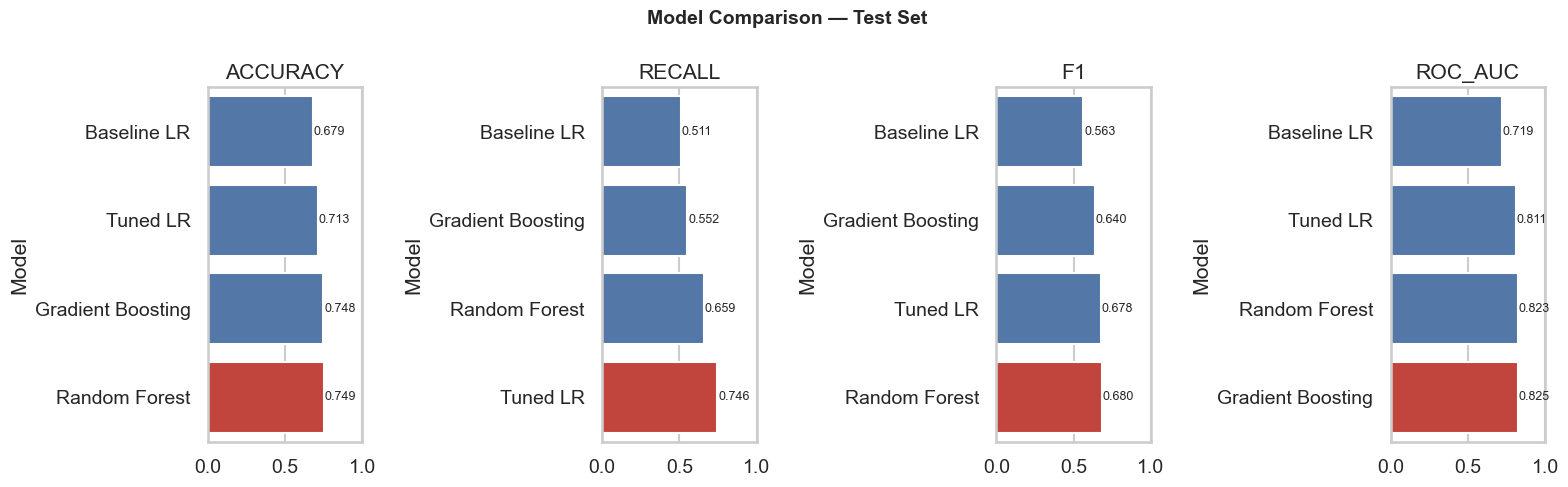

Saved: model_comparison.png


In [15]:

# ---------------------------------------------------------------------------
# CELL 15 – MODEL COMPARISON TABLE
# ---------------------------------------------------------------------------
# We compare all models on the same test set so the comparison is fair.
#
# Why RECALL matters most here:
#   A False Negative = the model says "this guest will show up" but they cancel.
#   The hotel blocks the room, turns away other guests, and loses the revenue.
#   Missing a cancellation is far more costly than a false alarm.
#   → We prioritise HIGH RECALL over High Precision.
#
# Why ROC-AUC:
#   AUC measures the model's ability to rank a cancellation higher than a
#   non-cancellation across all possible thresholds — a threshold-free measure.
#
# Why Brier Score (lower is better):
#   Measures how accurate the predicted PROBABILITIES are, not just the labels.
#   A model that says 0.99 for everything it gets right is overconfident —
#   Brier score penalises that.

comparison = pd.DataFrame(results_table).T.round(4)
comparison.index.name = "Model"

print("=" * 75)
print("MODEL COMPARISON — Test Set Metrics")
print("=" * 75)
print(comparison.to_string())
print("=" * 75)

# Highlight the winner for each metric
print("\n🏆 Best model per metric:")
for metric in comparison.columns:
    if metric in ["log_loss", "brier"]:
        winner = comparison[metric].idxmin()
        print(f"  {metric:12s}: {winner}  ({comparison.loc[winner, metric]:.4f}  ← lower is better)")
    else:
        winner = comparison[metric].idxmax()
        print(f"  {metric:12s}: {winner}  ({comparison.loc[winner, metric]:.4f})")

# Visual comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Model Comparison — Test Set", fontsize=14, fontweight="bold")

for ax, metric in zip(axes, ["accuracy", "recall", "f1", "roc_auc"]):
    vals = comparison[metric].sort_values()
    colors = ["#d73027" if i == 0 else "#4575b4" for i in range(len(vals))]
    sns.barplot(x=vals.values, y=vals.index, ax=ax, palette=colors[::-1])
    ax.set_title(metric.upper())
    ax.set_xlim(0, 1)
    for bar, val in zip(ax.patches, vals.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")



=== TOP 15 MOST IMPORTANT FEATURES (Tuned LR) ===
                      feature  coefficient  abs_coef  odds_ratio
      deposit_type_Non Refund     5.427436  5.427436  227.565051
  required_car_parking_spaces    -2.260826  2.260826    0.104264
                is_short_lead    -1.288685  1.288685    0.275633
            prior_cancel_rate     1.149285  1.149285    3.155936
     distribution_channel_GDS    -1.069423  1.069423    0.343207
 market_segment_Offline TA/TO    -1.036361  1.036361    0.354743
      customer_type_Transient     0.720194  0.720194    2.054831
     market_segment_Corporate    -0.624911  0.624911    0.535309
  distribution_channel_Direct    -0.623207  0.623207    0.536222
        market_segment_Groups    -0.588988  0.588988    0.554888
      deposit_type_Refundable    -0.575605  0.575605    0.562364
    total_of_special_requests    -0.564499  0.564499    0.568645
 market_segment_Complementary     0.540286  0.540286    1.716497
     market_segment_Online TA     0.4669

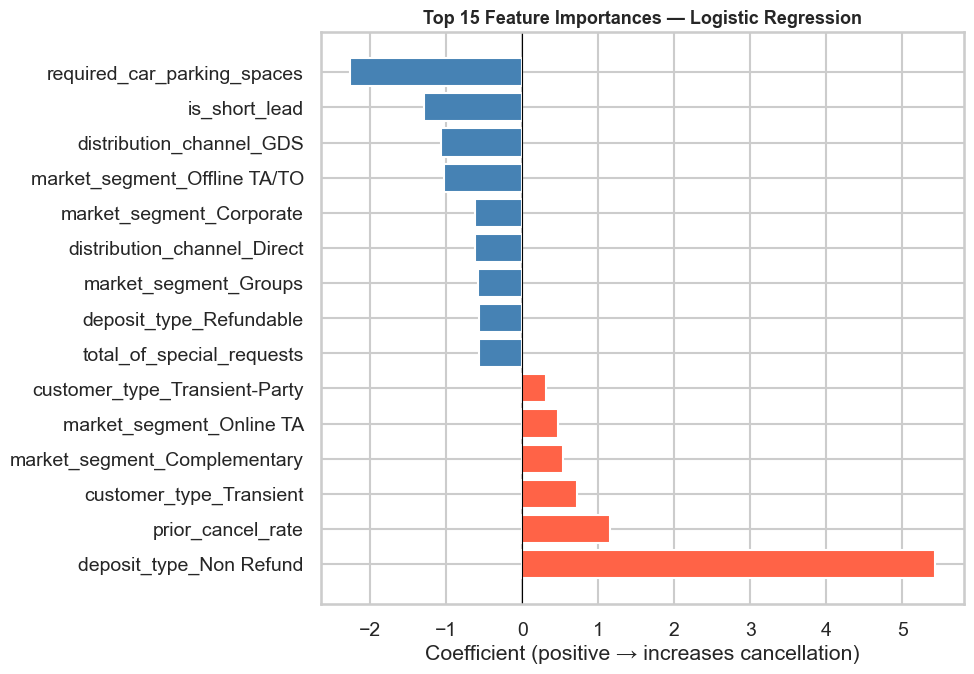

Saved: feature_importance.png

📊 Reading the chart:
  RED bars  → feature pushes TOWARDS cancellation (higher = more likely to cancel)
  BLUE bars → feature pushes AWAY from cancellation (higher = less likely to cancel)



In [16]:

# ---------------------------------------------------------------------------
# CELL 16 – FEATURE IMPORTANCE  (from the Tuned LR)
# ---------------------------------------------------------------------------
# Logistic Regression stores a coefficient for every feature.
# A positive coefficient means the feature increases the predicted probability
# of cancellation; negative means it decreases it.
#
# We compute the odds ratio = exp(coefficient):
#   odds_ratio > 1 → feature increases cancellation odds
#   odds_ratio < 1 → feature decreases cancellation odds
#   Example: odds_ratio = 2.5 means "this feature being 1 unit higher
#   makes cancellation 2.5× more likely, all else equal."
#
# We sort by |coefficient| so the most impactful features appear first.

clf_lr = final_lr_pipe.named_steps["clf"]
pre_lr = final_lr_pipe.named_steps["pre"]

feature_names = pre_lr.get_feature_names_out()
coefs         = clf_lr.coef_[0]

feat_imp = pd.DataFrame({
    "feature"    : feature_names,
    "coefficient": coefs,
    "abs_coef"   : np.abs(coefs),
    "odds_ratio" : np.exp(coefs),
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

print("=== TOP 15 MOST IMPORTANT FEATURES (Tuned LR) ===")
print(feat_imp.head(15).to_string(index=False))
print(f"\nIntercept: {clf_lr.intercept_[0]:.4f}")

# Plot top 15
top15 = feat_imp.head(15).sort_values("coefficient")
colors = ["tomato" if c > 0 else "steelblue" for c in top15["coefficient"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15["feature"], top15["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (positive → increases cancellation)")
ax.set_title("Top 15 Feature Importances — Logistic Regression",
             fontsize=13, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: feature_importance.png")

print("""
📊 Reading the chart:
  RED bars  → feature pushes TOWARDS cancellation (higher = more likely to cancel)
  BLUE bars → feature pushes AWAY from cancellation (higher = less likely to cancel)
""")



In [17]:

# ---------------------------------------------------------------------------
# CELL 17 – CONCLUSION
# ---------------------------------------------------------------------------

print("=" * 65)
print("CONCLUSION")
print("=" * 65)

base_auc   = results_table["Baseline LR"]["roc_auc"]
best_model = max(results_table, key=lambda m: results_table[m]["roc_auc"])
best_auc   = results_table[best_model]["roc_auc"]

print(f"""
This project built a hotel booking cancellation predictor on 119,390
real hotel reservations from Antonio et al. (2019).

Key steps and their impact:
  1. Leakage audit         → removed 2 columns that would "cheat"
  2. Hypothesis testing    → confirmed all 11 source features are
                             statistically significant (p < 0.05)
  3. Feature engineering   → 3 new features (prior_cancel_rate,
                             adr_per_person, is_short_lead)
  4. Time-based split      → honest evaluation on future data only
  5. Hyperparameter tuning → Optuna searched 10 parameter combinations

Performance lift:
  Baseline LR (raw features, no processing) : AUC = {base_auc:.4f}
  {best_model:40s}: AUC = {best_auc:.4f}
  Improvement: +{best_auc - base_auc:.4f} AUC points

The strongest predictors were deposit_type (Non Refund), lead_time,
and prior_cancel_rate — aligning with domain intuition that financial
commitment and booking-time behaviour are the clearest signals.
""")
print("=" * 65)

CONCLUSION

This project built a hotel booking cancellation predictor on 119,390
real hotel reservations from Antonio et al. (2019).

Key steps and their impact:
  1. Leakage audit         → removed 2 columns that would "cheat"
  2. Hypothesis testing    → confirmed all 11 source features are
                             statistically significant (p < 0.05)
  3. Feature engineering   → 3 new features (prior_cancel_rate,
                             adr_per_person, is_short_lead)
  4. Time-based split      → honest evaluation on future data only
  5. Hyperparameter tuning → Optuna searched 10 parameter combinations

Performance lift:
  Baseline LR (raw features, no processing) : AUC = 0.7194
  Gradient Boosting                       : AUC = 0.8248
  Improvement: +0.1054 AUC points

The strongest predictors were deposit_type (Non Refund), lead_time,
and prior_cancel_rate — aligning with domain intuition that financial
commitment and booking-time behaviour are the clearest signals.



In [ ]:
df.to_csv("..\data\processed\preocessed_data.csv", index=False)